In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
results_path = Path("./results")
zone = "Monterrey"

In [10]:
COLOR_MAP = {
    "Cultivos": "#B8860B",
    "Inundado": "#4169E1",
    "Bosques primarios": "#006400",
    "Bosques secundarios": "#228B22",
    "Pastizales": "#90EE90",
    "Otro": "#9932CC",
    "Pastizales\np/ganado": "#FFD700",
    "Asentamientos": "#808080",
    "Matorrales": "#FFA07A",
    "Humedales": "#40E0D0",
}

# Área histórica

Text(0, 0.5, 'Área (km²)')

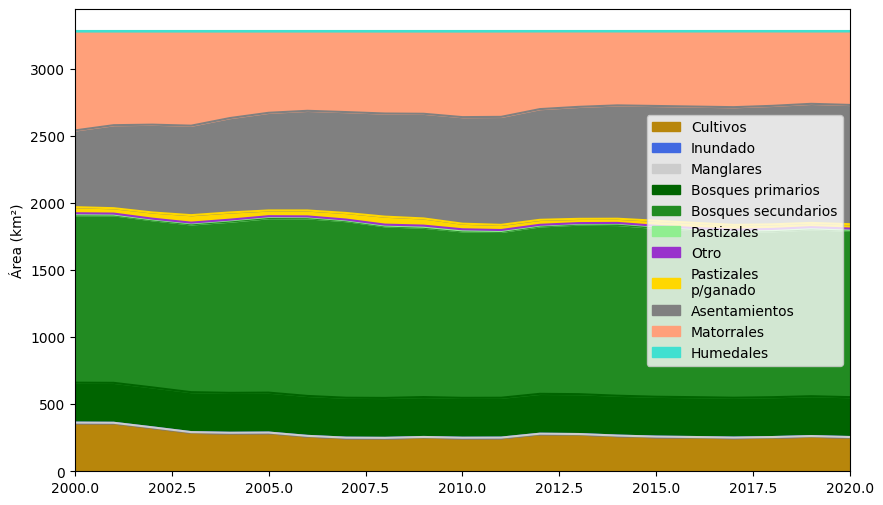

In [ ]:
df_area = pd.read_csv(results_path / "area" / f"{zone}.csv", index_col=0)

fig, ax = plt.subplots(figsize=(10, 6))
df_area.plot.area(
    ax=ax, color=[COLOR_MAP.get(col, "#CCCCCC") for col in df_area.columns]
)
ax.set_xlim(2000, 2020)
ax.set_xlabel("")
ax.set_ylabel("Área (km²)")

# Emisiones totales

Text(0.5, 0, '')

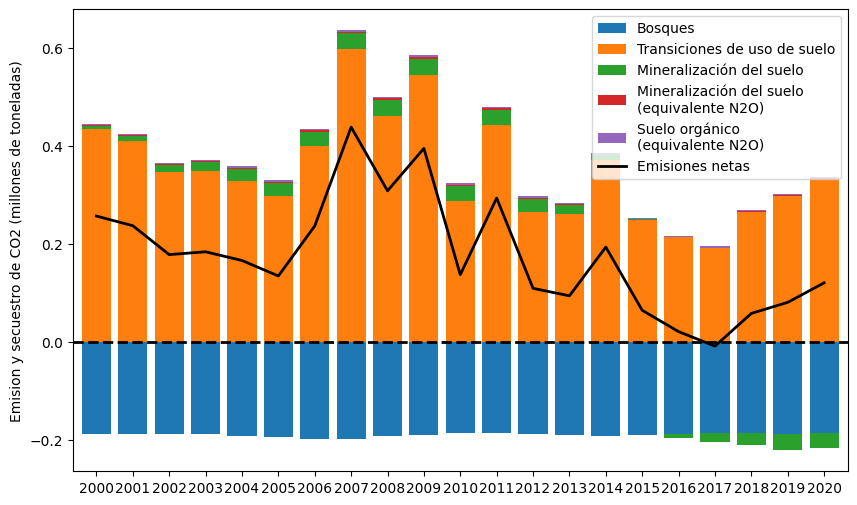

In [36]:
df_emissions = pd.read_csv(results_path / "emissions" / f"{zone}.csv", index_col=0)
net = (
    df_emissions.sum(axis=1)
    .rename("Emisiones netas")
    .to_frame()
    .reset_index(names="index")
    .assign(index=lambda df: df["index"].astype(str))
    .set_index("index")
)

fig, ax = plt.subplots(figsize=(10, 6))
df_emissions.plot.bar(stacked=True, ax=ax, width=0.8)
net.plot(ax=ax, color="black", linewidth=2)

ax.axhline(0, 0, 1, c="k", lw=2, ls="--")

ax.set_ylabel("Emision y secuestro de CO2 (millones de toneladas)")
ax.set_xlabel("")

# Emisiones por inicio / destino de tipo de uso de suelo

## Empezando en bosques

Esto te dice cuánto carbono fue emitido cuando un bosque se convirtió en cualquier otro tipo de uso de suelo

Text(0, 0.5, 'Emisiones de CO2 desde bosques (miles de toneladas)')

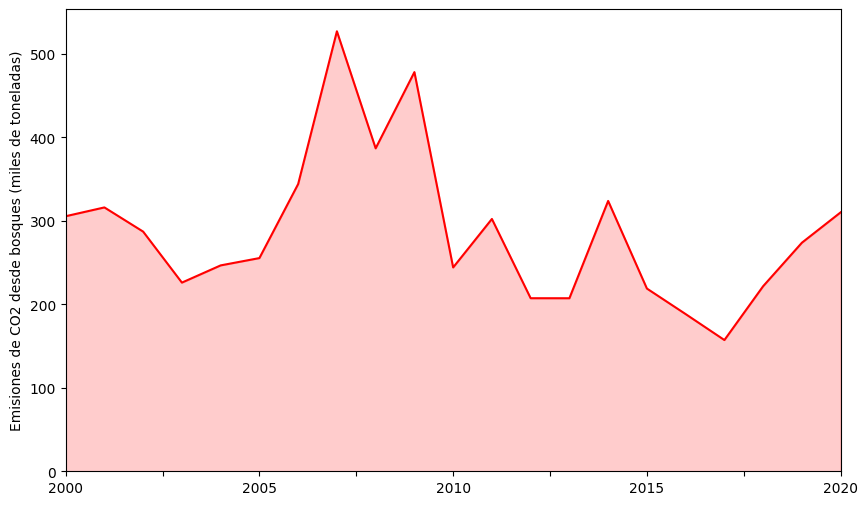

In [64]:
df_forests_start = (
    pd.read_csv(results_path / "emissions_from_forests" / f"{zone}.csv", index_col=0)
    .reset_index(names="index")
    .assign(index=lambda df: df["index"].astype(str))
    .set_index("index")
)

fig, ax = plt.subplots(figsize=(10, 6))
df_forests_start.plot(ax=ax, color="red", legend=False)
ax.fill_between(
    df_forests_start.index,
    df_forests_start["Emisiones (miles de toneladas CO2)"],
    color="red",
    alpha=0.2,
)
ax.set_xlim("2000", "2020")
ax.set_ylim(0, df_forests_start["Emisiones (miles de toneladas CO2)"].max() * 1.05)
ax.set_xlabel("")
ax.set_ylabel("Emisiones de CO2 desde bosques (miles de toneladas)")

# Terminando en asentamientos

Esto te dice cuánto carbono fue emitido cuando suelo de cualquier tipo se vuelve asentamientos

Text(0, 0.5, 'Emisiones de CO2 desde bosques (miles de toneladas)')

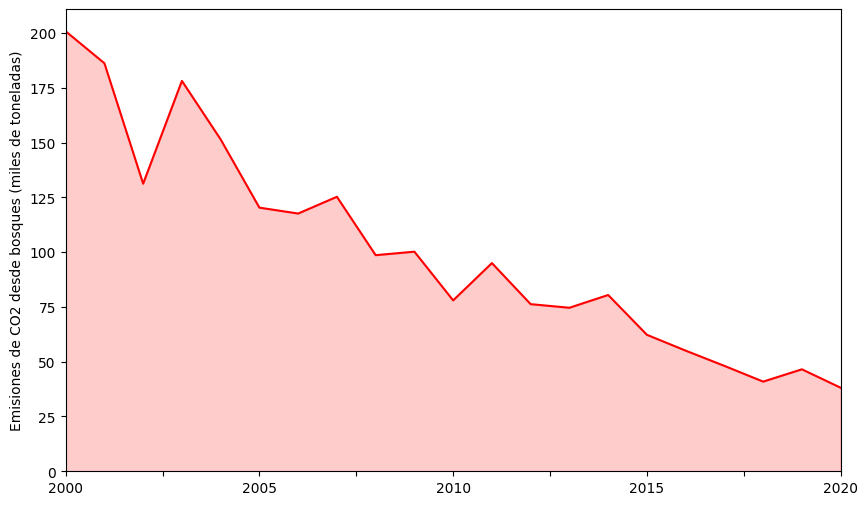

In [69]:
df_settlements_end = (
    pd.read_csv(results_path / "emissions_to_cities" / f"{zone}.csv", index_col=0)
    .reset_index(names="index")
    .assign(index=lambda df: df["index"].astype(str))
    .set_index("index")
)

fig, ax = plt.subplots(figsize=(10, 6))
df_settlements_end.plot(ax=ax, color="red", legend=False)
ax.fill_between(
    df_settlements_end.index,
    df_settlements_end["Emisiones (miles de toneladas CO2)"],
    color="red",
    alpha=0.2,
)
ax.set_xlim("2000", "2020")
ax.set_ylim(0, df_settlements_end["Emisiones (miles de toneladas CO2)"].max() * 1.05)
ax.set_xlabel("")
ax.set_ylabel("Emisiones de CO2 desde bosques (miles de toneladas)")